In [3]:
import numpy as np
import pandas as pd

In [4]:
def compute_demographic_distribution(fields_of_interest, df: pd.DataFrame):
    """Compute empirical distributions for each field of interest."""
    distributions = {}
    for key in fields_of_interest.keys():
        value_counts = df[key].value_counts(normalize=True).to_dict()
        distributions[key] = value_counts
    return distributions

In [13]:

fields_of_interest_2020 = {
    'V201549x': {
        "template": "Racially, the respondent is XXX.",
        "valmap": {1: 'white', 2: 'black', 3: 'asian', 4: 'native American', 5: 'hispanic'}
    },
    # 'V202022': {
    #     "template": "The respondent XXX.",
    #     "valmap": {
    #         1: 'likes to discuss politics with their family and friends',
    #         2: 'never discusses politics with their family or friends'
    #     }
    # },
    'V201200': {
        "template": "Ideologically, the respondent is XXX.",
        "valmap": {
            1: "extremely liberal",
            2: "liberal",
            3: "slightly liberal",
            4: "moderate",
            5: "slightly conservative",
            6: "conservative",
            7: "extremely conservative"
        }
    },
    'V201231x': {
        "template": "Politically, the respondent is XXX.",
        "valmap": {
            1: "a strong Democrat",
            2: "a weak Democrat",
            3: "an independent who leans Democratic",
            4: "an independent",
            5: "an independent who leans Republican",
            6: "a weak Republican",
            7: "a strong Republican"
        }
    },
    'V201452': {
        "template": "The respondent XXX.",
        "valmap": {1: "attends church", 2: "does not attend church"}
    },
    'V201507x': {
        "template": "The respondent is XXX years old.",
        "valmap": {}
    },
    'V201600': {
        "template": "The respondent is a XXX.",
        "valmap": {1: "man", 2: "woman"}
    },
    'V202406': {
        "template": "The respondent is XXX interested in politics.",
        "valmap": {1: "very", 2: "somewhat", 3: "not very", 4: "not at all"}
    }
}


In [14]:
ANES_FN = 'data/2020 ANES_test.csv'
SEP=','
df_2020 = pd.read_csv(ANES_FN, sep=SEP, encoding="latin-1", low_memory=False)
distributions_2020 = compute_demographic_distribution(fields_of_interest_2020, df_2020)

In [ ]:
fields_of_interest_2024 = {
    'V241501x': {
        "template": "Racially, I am XXX.",
        "valmap": {1: 'white', 2: 'black',  3: 'hispanic', 4: 'asian', 5: 'native American'}
    },
    # 'V202022': {
    #     "template": "The respondent XXX.",
    #     "valmap": {
    #         1: 'likes to discuss politics with their family and friends',
    #         2: 'never discusses politics with their family or friends'
    #     }
    # }, # the relevant question is V242025 but asking 'How many days in the past week did you talk about politics with family or friends?' and with different answer options, so removed
    'V241177':{
    # 'V241709': {
        "template": "Ideologically, I am XXX.",
        "valmap": {
            1: "extremely liberal",
            2: "liberal",
            3: "slightly liberal",
            4: "moderate",
            5: "slightly conservative",
            6: "conservative",
            7: "extremely conservative"
        }
    },
    'V241227x': {
        "template": "Politically, I am XXX.",
        "valmap": {
            1: "a strong democrat",
            2: "a weak Democrat",
            3: "an independent who leans Democratic",
            4: "an independent",
            5: "an independent who leans Republican",
            6: "a weak Republican",
            7: "a strong Republican"
        }
    },
    'V241439': {
        "template": "I XXX.",
        "valmap": {1: "attend church", 2: "do not attend church"}
    },
    'V241458x': {
        "template": "I am XXX years old.",
        "valmap": {}
    },
    'V241550': {
        "template": "I am a XXX.",
        "valmap": {1: "man", 2: "woman"}
    },
    'V242400': {
        "template": "I am XXX interested in politics.",
        "valmap": {1: "very", 2: "somewhat", 3: "not very", 4: "not at all"}
    }
}


In [236]:
ANES_FN = 'data/2024 ANES_test.csv'
SEP=','
df_2024 = pd.read_csv(ANES_FN, sep=SEP, encoding="latin-1", low_memory=False)
distributions_2024 = compute_demographic_distribution(fields_of_interest_2024, df_2024)

In [268]:
invalid_rate_list_2024 = []
ideology_2024 = []
politics_interests_2024 = []
for key in distributions_2024:
    print(key,distributions_2024[key])
    invalid_rate = 0
    for k in distributions_2024[key]:
        if k < 0 or (k == 99 and key not in ['V241458x']):
            # print(k,distributions_2024[key][k])
            invalid_rate += distributions_2024[key][k]
    print('invalid_rate =',invalid_rate)
    invalid_rate_list_2024.append(round(invalid_rate,3))

V241501x {1: 0.7147255931896396, 3: 0.10541568556420938, 2: 0.0920123166093099, 4: 0.03568194167723238, 6: 0.03405180220974461, -9: 0.011410976272414417, 5: 0.005977178047455171, -4: 0.0005433798224959246, -8: 0.00018112660749864155}
invalid_rate = 0.012135482702408983
V241177 {4: 0.21499728310088753, 6: 0.1865604057236008, 2: 0.14834269154138743, 99: 0.1302300307915233, 5: 0.10758920485419309, 3: 0.09835174787176236, 7: 0.05596812171708024, 1: 0.045281651874660385, -9: 0.012135482702408985, -4: 0.0005433798224959246}
invalid_rate = 0.1429088933164282
V241227x {1: 0.238000362253215, 7: 0.21119362434341604, 5: 0.12968665096902735, 3: 0.12932439775403007, 2: 0.1115739902191632, 6: 0.10451005252671618, 4: 0.06882811084948379, -9: 0.005614924832457888, -8: 0.0009056330374932077, -4: 0.0003622532149972831}
invalid_rate = 0.006882811084948378
V241439 {1: 0.49284549900380364, 2: 0.45662017750407535, -1: 0.04437601883716718, -9: 0.005977178047455171, -8: 0.00018112660749864155}
invalid_rate = 

In [279]:
distributions_2024['V241177']

ideology_2024 = [distributions_2024['V241177'][v] for v in range(1,8)]
ideology_2024

[0.045281651874660385,
 0.14834269154138743,
 0.09835174787176236,
 0.21499728310088753,
 0.10758920485419309,
 0.1865604057236008,
 0.05596812171708024]

In [320]:

party_2024 = [distributions_2024['V241227x'][v] for v in range(1,8)]
party_2024

[0.238000362253215,
 0.1115739902191632,
 0.12932439775403007,
 0.06882811084948379,
 0.12968665096902735,
 0.10451005252671618,
 0.21119362434341604]

In [286]:
politics_interests_2024  = [distributions_2024['V242400'][v] for v in range(1,5)]
politics_interests_2024

[0.1974280021735193,
 0.4245607679768158,
 0.18547364607860894,
 0.0824126064118819]

In [231]:
invalid_rate_list_2020 = []

for key in distributions_2020:
    print(key,distributions_2020[key])
    invalid_rate = 0
    for k in distributions_2020[key]:
        if k < 0 or (k == 99 and key not in ['V201507x']):
            # print(k,distributions_2020[key][k])
            invalid_rate += distributions_2020[key][k]
    print('invalid_rate =',invalid_rate)
    invalid_rate_list_2020.append(round(invalid_rate,3))

V201549x {1: 0.7175151626539239, 2: 0.08968939533174049, 3: 0.0880352876309502, 4: 0.036206579672854254, 6: 0.033082154015805915, 5: 0.021135820621209337, -9: 0.013232861606322368, -8: 0.0011027384671935306}
invalid_rate = 0.014335600073515899
V201200 {4: 0.2251424370520125, 6: 0.17221099062672302, 99: 0.14923727256019115, 2: 0.14482631869141702, 3: 0.11321448263186915, 5: 0.1007167800036758, 7: 0.04613122587759603, 1: 0.04447711817680573, -9: 0.003675794890645102, -8: 0.0003675794890645102}
invalid_rate = 0.15328064693990076
V201231x {1: 0.23102370887704465, 7: 0.20253629847454513, 3: 0.12387428781473994, 4: 0.11983091343503033, 2: 0.11082521595294982, 5: 0.10586289285057894, 6: 0.09979783128101452, -9: 0.005513692335967653, -8: 0.0007351589781290203}
invalid_rate = 0.006248851314096673
V201452 {2: 0.5193898180481529, 1: 0.4721558537033633, -9: 0.00790295901488697, -8: 0.0005513692335967653}
invalid_rate = 0.008454328248483734
V201507x {-9: 0.0470501746002573, 80: 0.04631501562212829,

In [277]:
distributions_2020['V201200']
ideology_2020 = [distributions_2020['V201200'][v] for v in range(1,8)]
ideology_2020

[0.04447711817680573,
 0.14482631869141702,
 0.11321448263186915,
 0.2251424370520125,
 0.1007167800036758,
 0.17221099062672302,
 0.04613122587759603]

In [321]:
party_2020 = [distributions_2020['V201231x'][v] for v in range(1,8)]
party_2020

[0.23102370887704465,
 0.11082521595294982,
 0.12387428781473994,
 0.11983091343503033,
 0.10586289285057894,
 0.09979783128101452,
 0.20253629847454513]

In [288]:
politics_interests_2020  = [distributions_2020['V202406'][v] for v in range(1,5)]
politics_interests_2020

[0.2144826318691417,
 0.4179378790663481,
 0.16798382650248117,
 0.0683697849659989]

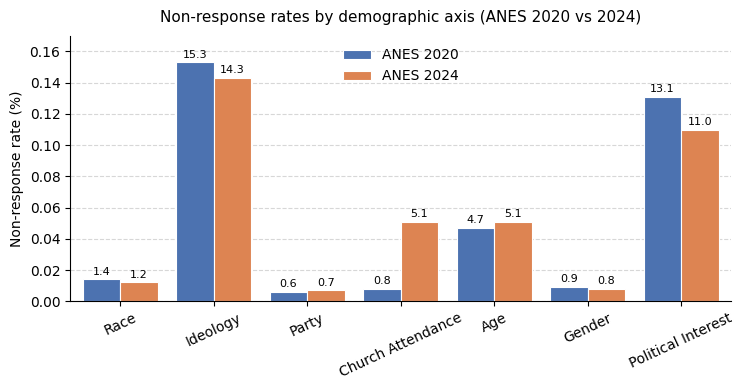

In [303]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Prepare your data
# Replace these labels with your actual demographic variable names
groups = ['Race', 'Ideology', 'Party', 'Church Attendance', 'Age', 'Gender', 'Political Interest']

x = np.arange(len(groups))  # Label locations
width = 0.4               # Width of the bars

# 2. Create the plot
fig, ax = plt.subplots(figsize=(7.6, 4))

# Plotting 2020 and 2024 bars
rects1 = ax.bar(x - width/2, invalid_rate_list_2020, width, label='ANES 2020', 
                color='#4C72B0', edgecolor='white', linewidth=0.8)
rects2 = ax.bar(x + width/2, invalid_rate_list_2024, width, label='ANES 2024', 
                color='#DD8452', edgecolor='white', linewidth=0.8)

# 3. Add Styling
ax.set_ylabel('Non-response rate (%)')
ax.set_title('Non-response rates by demographic axis (ANES 2020 vs 2024)', 
             pad=10)
ax.set_xticks(x)
ax.set_xticklabels(groups, rotation=25, ha='center')

ax.legend(loc='best', frameon=False, ncol=1)
ax.set_ylim(0, 0.17) 

# Add a light grid for readability
ax.yaxis.grid(True, linestyle='--', alpha=0.6, zorder=0)
ax.set_axisbelow(True)
# ax.set_yscale('log')
# 4. Add data labels on top of the bars
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height*100:.1f}',
                        xy=(rect.get_x() + rect.get_width() / 2, height),
                        xytext=(0, 2), textcoords="offset points",
                        ha='center', va='bottom', fontsize=8)

autolabel(rects1)
autolabel(rects2)
ax.yaxis.grid(True, linestyle='--', alpha=0.5)

ax.set_xmargin(0.02)
# Remove the top and right spines for a modern look
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.rcParams.update({
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
})
fig.tight_layout() 

plt.show()
fig.savefig(
            'nonresponse.pdf',
            format="pdf",
            bbox_inches="tight",     # removes extra margins
            pad_inches=0.05,         # small padding
            dpi=300                  # high quality
        )


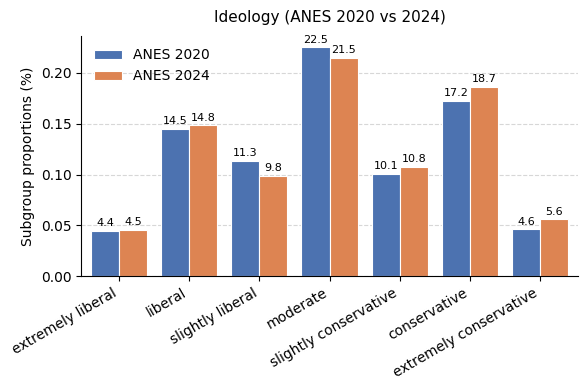

In [330]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Prepare your data
# Replace these labels with your actual demographic variable names
groups = ['Race', 'Ideology', 'Party', 'Church Attendance', 'Age', 'Gender', 'Political Interest']

groups = [fields_of_interest_2024['V241177']['valmap'][v] for v in range(1,8)]
x = np.arange(len(groups))  # Label locations
width = 0.4               # Width of the bars

# 2. Create the plot
fig, ax = plt.subplots(figsize=(6, 4))

# Plotting 2020 and 2024 bars
rects1 = ax.bar(x - width/2, ideology_2020, width, label='ANES 2020', 
                color='#4C72B0', edgecolor='white', linewidth=0.8)
rects2 = ax.bar(x + width/2, ideology_2024, width, label='ANES 2024', 
                color='#DD8452', edgecolor='white', linewidth=0.8)

# 3. Add Styling
ax.set_ylabel('Subgroup proportions (%)')
ax.set_title('Ideology (ANES 2020 vs 2024)', 
             pad=10)
ax.set_xticks(x)
ax.set_xticklabels(groups, rotation=30, ha='right')

ax.legend(loc='best', frameon=False, ncol=1)
# ax.set_ylim(0, 0.17) 

# Add a light grid for readability
ax.yaxis.grid(True, linestyle='--', alpha=0.6, zorder=0)
ax.set_axisbelow(True)
# ax.set_yscale('log')
# 4. Add data labels on top of the bars
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height*100:.1f}',
                        xy=(rect.get_x() + rect.get_width() / 2, height),
                        xytext=(0, 2), textcoords="offset points",
                        ha='center', va='bottom', fontsize=8)

autolabel(rects1)
autolabel(rects2)
ax.yaxis.grid(True, linestyle='--', alpha=0.5)

ax.set_xmargin(0.02)
# Remove the top and right spines for a modern look
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.rcParams.update({
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
})
fig.tight_layout() 

plt.show()
fig.savefig(
            'ideology_dist_diff.pdf',
            format="pdf",
            bbox_inches="tight",     # removes extra margins
            pad_inches=0.05,         # small padding
            dpi=300                  # high quality
        )


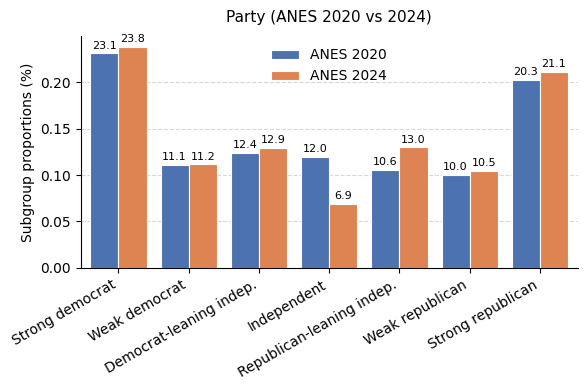

In [329]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Prepare your data
# Replace these labels with your actual demographic variable names
groups = ['Strong democrat', 'Weak democrat', 'Democrat-leaning indep.', 'Independent', 'Republican-leaning indep.', 'Weak republican', 'Strong republican']

# groups = [fields_of_interest_2020['V201231x']['valmap'][v] for v in range(1,8)]
x = np.arange(len(groups))  # Label locations
width = 0.4               # Width of the bars

# 2. Create the plot
fig, ax = plt.subplots(figsize=(6, 4))

# Plotting 2020 and 2024 bars
rects1 = ax.bar(x - width/2, party_2020, width, label='ANES 2020', 
                color='#4C72B0', edgecolor='white', linewidth=0.8)
rects2 = ax.bar(x + width/2, party_2024, width, label='ANES 2024', 
                color='#DD8452', edgecolor='white', linewidth=0.8)

# 3. Add Styling
ax.set_ylabel('Subgroup proportions (%)')
ax.set_title('Party (ANES 2020 vs 2024)', 
             pad=10)
ax.set_xticks(x)
ax.set_xticklabels(groups, rotation=30, ha='right')

ax.legend(loc='best', frameon=False, ncol=1)
# ax.set_ylim(0, 0.17) 

# Add a light grid for readability
ax.yaxis.grid(True, linestyle='--', alpha=0.6, zorder=0)
ax.set_axisbelow(True)
# ax.set_yscale('log')
# 4. Add data labels on top of the bars
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height*100:.1f}',
                        xy=(rect.get_x() + rect.get_width() / 2, height),
                        xytext=(0, 2), textcoords="offset points",
                        ha='center', va='bottom', fontsize=8)

autolabel(rects1)
autolabel(rects2)
ax.yaxis.grid(True, linestyle='--', alpha=0.5)

ax.set_xmargin(0.02)
# Remove the top and right spines for a modern look
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.rcParams.update({
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
})
fig.tight_layout() 

plt.show()
fig.savefig(
            'party_dist_diff.pdf',
            format="pdf",
            bbox_inches="tight",     # removes extra margins
            pad_inches=0.05,         # small padding
            dpi=300                  # high quality
        )


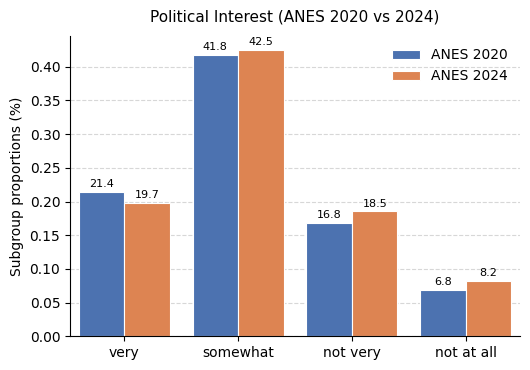

In [337]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Prepare your data
# Replace these labels with your actual demographic variable names

groups = [fields_of_interest_2024['V242400']['valmap'][v] for v in range(1,5)]
x = np.arange(len(groups))  # Label locations
width = 0.4               # Width of the bars

# 2. Create the plot
fig, ax = plt.subplots(figsize=(5.4, 3.8))

# Plotting 2020 and 2024 bars
rects1 = ax.bar(x - width/2, politics_interests_2020, width, label='ANES 2020', 
                color='#4C72B0', edgecolor='white', linewidth=0.8)
rects2 = ax.bar(x + width/2, politics_interests_2024, width, label='ANES 2024', 
                color='#DD8452', edgecolor='white', linewidth=0.8)

# 3. Add Styling
ax.set_ylabel('Subgroup proportions (%)')
ax.set_title('Political Interest (ANES 2020 vs 2024)', 
             pad=10)
ax.set_xticks(x)
ax.set_xticklabels(groups, rotation=0, ha='center')

ax.legend(loc='best', frameon=False, ncol=1)
# ax.set_ylim(0, 0.5) 

# Add a light grid for readability
ax.yaxis.grid(True, linestyle='--', alpha=0.6, zorder=0)
ax.set_axisbelow(True)
# ax.set_yscale('log')
# 4. Add data labels on top of the bars
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height*100:.1f}',
                        xy=(rect.get_x() + rect.get_width() / 2, height),
                        xytext=(0, 2), textcoords="offset points",
                        ha='center', va='bottom', fontsize=8)

autolabel(rects1)
autolabel(rects2)
ax.yaxis.grid(True, linestyle='--', alpha=0.5)

ax.set_xmargin(0.02)
# Remove the top and right spines for a modern look
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.rcParams.update({
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
})
fig.tight_layout() 

plt.show()
fig.savefig(
            'pol-interest_dist_diff.pdf',
            format="pdf",
            bbox_inches="tight",     # removes extra margins
            pad_inches=0.05,         # small padding
            dpi=300                  # high quality
        )


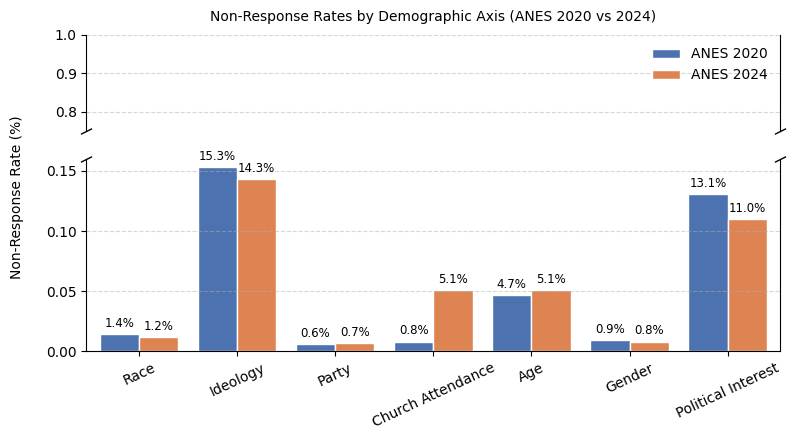

In [228]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Data
groups = ['Race', 'Ideology', 'Party', 'Church Attendance', 'Age', 'Gender', 'Political Interest']
# One big outlier (Church) and several small ones
x = np.arange(len(groups))
width = 0.4

# 2. Create subplots with height_ratios and MINIMAL hspace
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=(8, 4.5), 
                               gridspec_kw={'height_ratios': [1, 2]})

# This is the "space" controller. 0.02 is almost touching.
fig.subplots_adjust(hspace=0.05) 

# 3. Plot bars on both
ax1.bar(x - width/2, invalid_rate_list_2020, width, color='#4C72B0', edgecolor='white', label='ANES 2020')
ax1.bar(x + width/2, invalid_rate_list_2024, width, color='#DD8452', edgecolor='white', label='ANES 2024')
ax2.bar(x - width/2, invalid_rate_list_2020, width, color='#4C72B0', edgecolor='white')
ax2.bar(x + width/2, invalid_rate_list_2024, width, color='#DD8452', edgecolor='white')

# 4. Zoom limits
ax1.set_ylim(0.75, 1)  # Adjust based on your highest value
ax2.set_ylim(0, 0.16)    # Adjust based on your small values

# 5. Hide the interior spines
ax1.spines['bottom'].set_visible(False)
ax2.spines['top'].set_visible(False)

# Clean up ticks
ax1.tick_params(bottom=False) 
ax2.tick_params(top=False)

ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(True)
ax1.spines['bottom'].set_visible(False)   # optional
ax1.spines['left'].set_visible(True)     # optional

ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(True)
ax2.spines['bottom'].set_visible(True)   # optional
ax2.spines['left'].set_visible(True)     # optional

ax1.yaxis.grid(True, linestyle='--', alpha=0.5)
ax2.yaxis.grid(True, linestyle='--', alpha=0.5)

# 6. The "Official" Slanted Lines Marker Trick
# This makes the break look professional regardless of the gap size
d = .5  # proportion of vertical to horizontal extent of the slanted line
kwargs = dict(marker=[(-1, -d), (1, d)], markersize=8,
              linestyle="none", color='k', mec='k', mew=1, clip_on=False)

ax1.plot([0, 1], [0, 0], transform=ax1.transAxes, **kwargs)
ax2.plot([0, 1], [1, 1], transform=ax2.transAxes, **kwargs)

# 7. Labels & Formatting
ax2.set_xticks(x)
# ax2.set_xticklabels(groups)
ax2.set_xticklabels(groups, rotation=25, ha='center')
ax2.set_ylabel('Non-Response Rate (%)' )
ax2.yaxis.set_label_coords(-0.09, 0.8) # Centers label across the break
ax1.set_title('Non-Response Rates by Demographic Axis (ANES 2020 vs 2024)', 
              pad=10)
ax1.set_xmargin(0.02)
ax2.set_xmargin(0.02)
# Function to add text labels (corrected for broken axes)
def autolabel(rects, ax, vmin, vmax):
    for rect in rects:
        h = rect.get_height()
        if vmin <= h <= vmax:
            ax.annotate(f'{h*100:.1f}%', xy=(rect.get_x() + rect.get_width()/2, h),
                        xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontsize=8.5)

autolabel(ax1.patches[:7], ax1, 0.75, 1) # 2020 top
autolabel(ax1.patches[7:], ax1, 0.75, 1) # 2024 top
autolabel(ax2.patches[:7], ax2, 0, 0.16)    # 2020 bottom
autolabel(ax2.patches[7:], ax2, 0, 0.16)    # 2024 bottom
# ax1.legend(loc='best', frameon=False)
# ax2.legend(loc='best', frameon=False)
# ax1.legend(loc='upper left', frameon=False, fontsize=10)
ax1.legend(loc='best', frameon=False, fontsize=10)
plt.rcParams.update({
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
})
fig.tight_layout() 

plt.show()
# fig.savefig(
#             'nonresponse.pdf',
#             format="pdf",
#             bbox_inches="tight",     # removes extra margins
#             pad_inches=0.05,         # small padding
#             dpi=300                  # high quality
#         )